# EDP2 starter notebook

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

## Setup

In [1]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

In [ ]:
# Setup
from dask.distributed import Client

client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask dashboard: {client.dashboard_link}")

## Open catalog

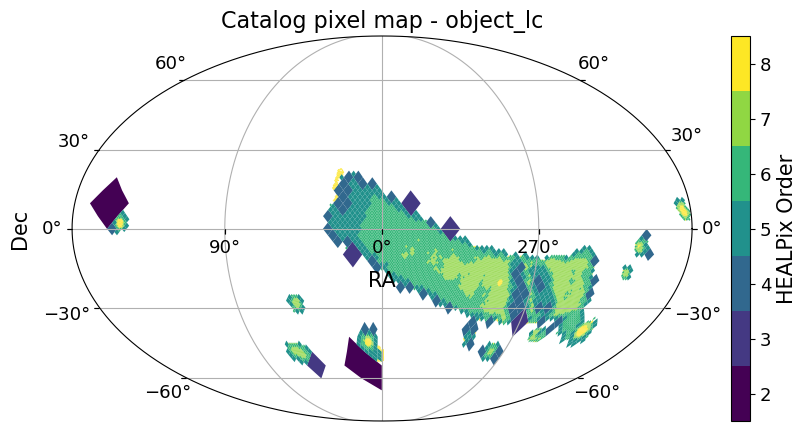

In [4]:
# Open DP2 catalog and plot
# Path on RSP
base_path = UPath("/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2_rc")
cat = lsdb.open_catalog(base_path / "object_collection")
cat.plot_pixels();

In [5]:
# Choose catalog
# Object catalog: "object_collection"
# DiaObject catalog: "dia_object_collection"
cat = (
    lsdb.open_catalog(
        base_path / "object_collection",
        # Select columns
        # Column descriptions available at https://sdm-schemas.lsst.io/dp2.html
        columns=["g_psfMag", "r_psfMag"],
        # Select a sky region
    )
    .cone_search(
        ra=10.0,
        dec=-5.0,
        radius_arcsec=2 * 3600,
        # Query on column values
    )
    .query("g_psfMag < 28.0 and r_psfMag < 28.0")
)

In [6]:
# Check catalog
cat

,g_psfMag,r_psfMag,coord_ra,coord_dec
npartitions=19,,,,
"Order: 5, Pixel: 4482",float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...
"Order: 6, Pixel: 17971",...,...,...,...
"Order: 6, Pixel: 17976",...,...,...,...


## Plot skymaps

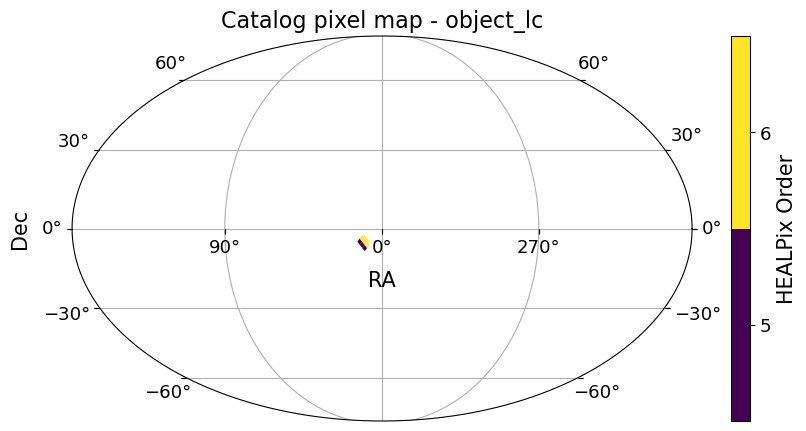

In [7]:
# Plot catalog
cat.plot_pixels();

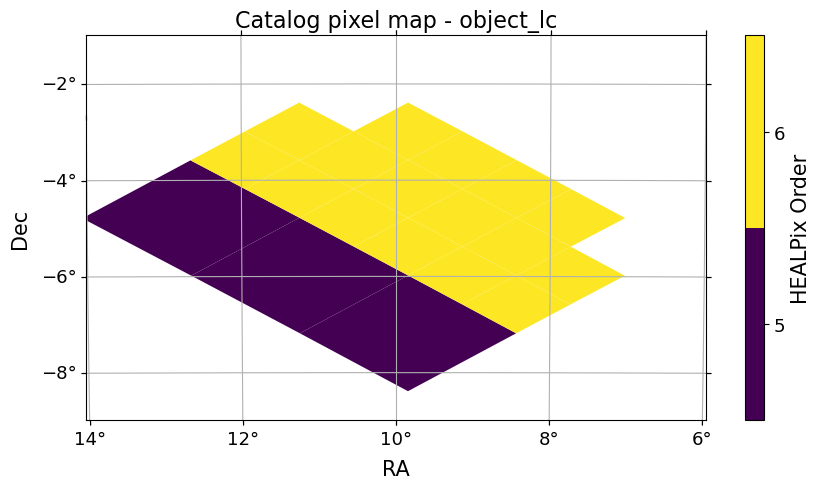

In [8]:
# Plot zoomed catalog
import astropy.units as u

fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(10 * u.deg, -5 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

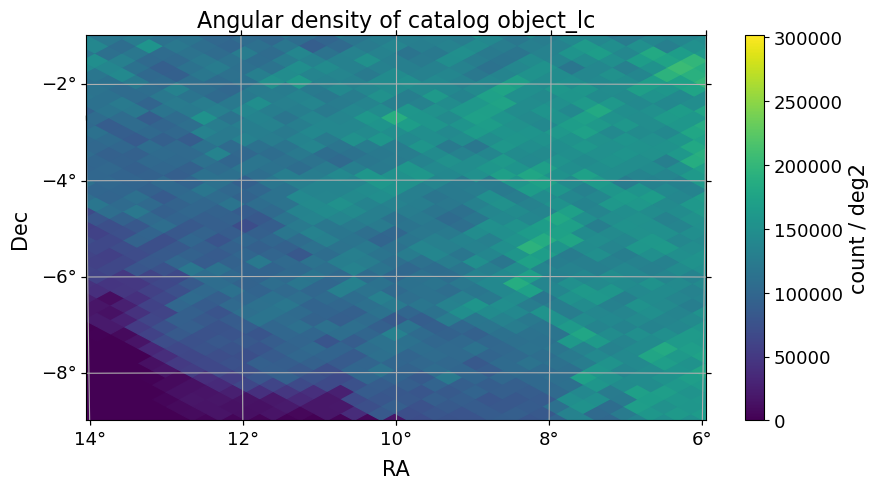

In [9]:
# Plot density
import hats

hats.inspection.plot_density(cat.hc_structure, ec="face", projection="AIT", fov=fov, center=center);

## Map a function

In [10]:
# Map a function


# The mappable function takes in a dataframe that represents a partition.
# It returns a dataframe.
def g_minus_r_mapper(df):
    df["g_minus_r_mag"] = df["g_psfMag"] - df["r_psfMag"]
    return df


cat = cat.map_partitions(g_minus_r_mapper)

## Compute catalog

In [11]:
# Check catalog before computing
cat.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,
1261770054783963537,23.567427,27.750866,9.387727,-6.903804,-4.183439
1261770060486994182,25.459435,25.13032,9.386266,-6.903903,0.329115
1261770060491471999,23.589426,24.084002,9.386552,-6.903749,-0.494576
1261770060628372753,23.302301,25.299643,9.385689,-6.903057,-1.997341
1261770062830375321,25.315023,25.074331,9.383639,-6.900418,0.240692


In [12]:
# Compute catalog and write to disk
cat.write_catalog("dp2_example_cat", overwrite=True)

Writing Catalog:   0%|          | 0/19 [00:00<?, ?it/s]

Writing Margin Cache:   0%|          | 0/24 [00:00<?, ?it/s]

In [13]:
# Compute catalog to dataframe
df = cat.compute()

Computing Catalog:   0%|          | 0/19 [00:00<?, ?it/s]

In [14]:
df

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,
1261770054783963537,23.567427,27.750866,9.387727,-6.903804,-4.183439
1261770060486994182,25.459435,25.13032,9.386266,-6.903903,0.329115
...,...,...,...,...,...
1264957488779219710,23.485807,23.111719,9.642696,-3.406365,0.374088
1264957490399993435,23.47562,22.966101,9.636538,-3.40503,0.50952


In [15]:
# Read catalog from disk
cat = lsdb.open_catalog("dp2_example_cat")

## Crossmatch

In [16]:
# Crossmatch
des_cat = lsdb.open_catalog("s3://stpubdata/mast/public/des/hats/des_dr2/", columns=["MAG_AUTO_G"])
des_cat

,MAG_AUTO_G,RA,DEC
npartitions=1582,,,
"Order: 4, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...
"Order: 6, Pixel: 47556",...,...,...
"Order: 1, Pixel: 47",...,...,...


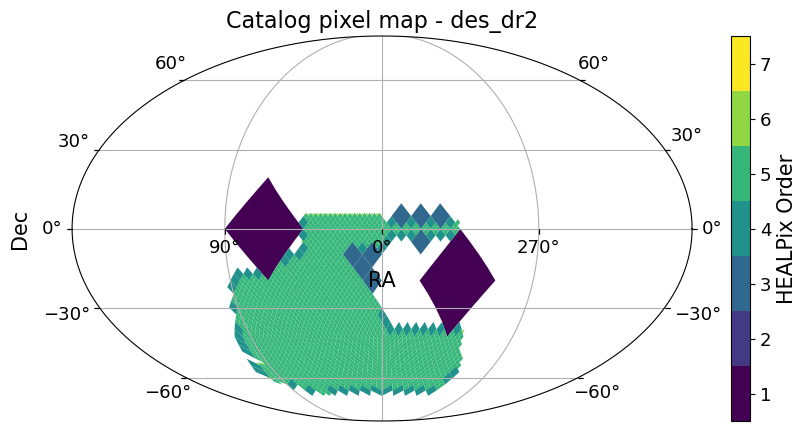

In [17]:
des_cat.plot_pixels();

In [18]:
# Crossmatch LSST catalog with Gaia catalog
x_cat = cat.crossmatch(
    des_cat,
    suffix_method="overlapping_columns",
)

In [19]:
x_cat.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag,MAG_AUTO_G,RA,DEC,_dist_arcsec
_healpix_29,,,,,,,,,
1261772975348269355,22.824999,21.217491,9.354591,-6.763164,1.607508,22.549606,9.354593,-6.763168,0.016437
1261772979210506070,23.712337,22.337854,9.343584,-6.76523,1.374483,22.570774,9.343664,-6.765238,0.288975
1261772981394880982,25.01685,23.876198,9.35136,-6.762464,1.140652,24.032064,9.351434,-6.76249,0.281369
1261772981413236414,22.785107,21.315828,9.350297,-6.763012,1.469278,22.043205,9.350302,-6.763015,0.022969
1261772981529417225,23.926285,22.162642,9.350745,-6.761828,1.763643,23.699547,9.350747,-6.761827,0.007049


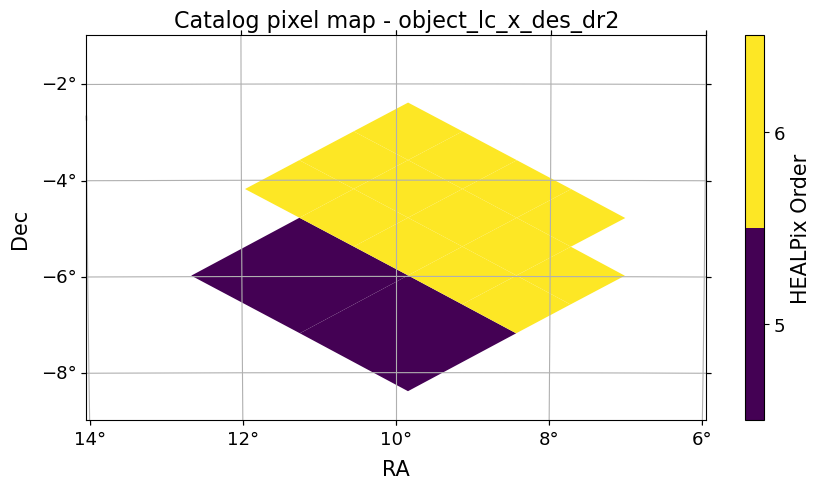

In [20]:
x_cat.plot_pixels(projection="AIT", fov=fov, center=center);

In [21]:
x_df = x_cat.compute()

Computing Catalog:   0%|          | 0/16 [00:00<?, ?it/s]

In [22]:
x_df

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag,MAG_AUTO_G,RA,DEC,_dist_arcsec
_healpix_29,,,,,,,,,
1261772975348269355,22.824999,21.217491,9.354591,-6.763164,1.607508,22.549606,9.354593,-6.763168,0.016437
1261772979210506070,23.712337,22.337854,9.343584,-6.76523,1.374483,22.570774,9.343664,-6.765238,0.288975
...,...,...,...,...,...,...,...,...,...
1264957488779219710,23.485807,23.111719,9.642696,-3.406365,0.374088,23.457121,9.6427,-3.406363,0.017579
1264957490399993435,23.47562,22.966101,9.636538,-3.40503,0.50952,22.97908,9.636515,-3.405052,0.116141


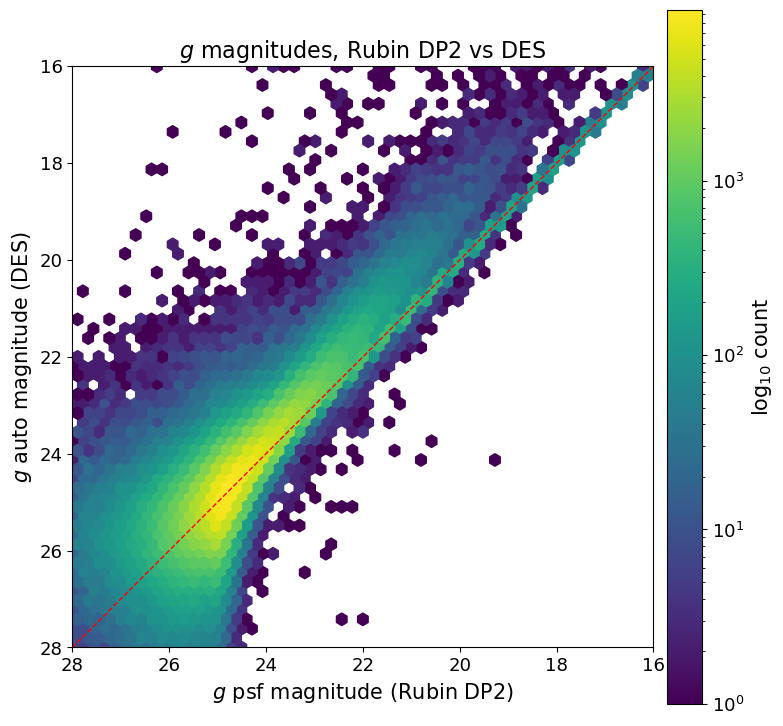

In [ ]:
mag_lo, mag_hi = 16.0, 28.0

fig, ax = plt.subplots(figsize=(8, 7.5))
hb = ax.hexbin(
    x_df["g_psfMag"],
    x_df["MAG_AUTO_G"],
    gridsize=55,
    bins="log",
    extent=(mag_lo, mag_hi, mag_lo, mag_hi),
    mincnt=1,
    cmap="viridis",
)
ax.plot([mag_lo, mag_hi], [mag_lo, mag_hi], "r--", lw=1)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("log$_{10}$ count")

ax.set_xlim(mag_hi, mag_lo)
ax.set_ylim(mag_hi, mag_lo)
ax.set_aspect("equal")
ax.set_xlabel("$g$ psf magnitude (Rubin DP2)")
ax.set_ylabel("$g$ auto magnitude (DES)")
ax.set_title("$g$ magnitudes, Rubin DP2 vs DES")

fig.tight_layout()
plt.show()

In [25]:
# Clean up
client.close()